## Imports

In [1]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data import Data
from layers import DenseLayer
from activation import ReLUActivation, SoftmaxActivation
from neuralnet import NeuralNetwork
from losses import CategoricalCrossEntropy
from metrics import accuracy

## Ler os datasets

In [2]:
train_df = pd.read_csv("../dataset-exemplos.csv", sep=";")
test_df = pd.read_csv("../subm1.csv", sep=";")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Train shape: (125, 3)
Test shape: (150, 2)


,ID,Text,Label
0,D1-1,"It is an approximation useful in chemistry, bu...",Human
1,D1-2,"PET scanning, or Positron Emission Tomography,...",Meta
2,D1-3,Positron Emission Tomography (PET) scanning is...,Google
3,D1-4,Thermonuclear fusion is the process of combini...,Meta
4,D1-5,"These nutrients are needed to keep bones, teet...",Human


,ID,Text
0,D2-1,A covalent bond is a chemical bond that involv...
1,D2-2,A covalent bond forms when two atoms share one...
2,D2-3,A covalent bond is a type of chemical bond whe...
3,D2-4,A covalent bond is a chemical bond that involv...
4,D2-5,Driven by exciting developments in the field o...


## Limpeza de texto

In [3]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean_text"] = train_df["Text"].apply(clean_text)
test_df["clean_text"] = test_df["Text"].apply(clean_text)

display(train_df[["Text", "clean_text", "Label"]].head())

,Text,clean_text,Label
0,"It is an approximation useful in chemistry, bu...",it is an approximation useful in chemistry but...,Human
1,"PET scanning, or Positron Emission Tomography,...",pet scanning or positron emission tomography i...,Meta
2,Positron Emission Tomography (PET) scanning is...,positron emission tomography pet scanning is a...,Google
3,Thermonuclear fusion is the process of combini...,thermonuclear fusion is the process of combini...,Meta
4,"These nutrients are needed to keep bones, teet...",these nutrients are needed to keep bones teeth...,Human


## Ver classes

In [4]:
print("Classes:")
print(train_df["Label"].value_counts())

Classes:
Label
Human        52
Anthropic    23
Meta         17
OpenAI       17
Google       16
Name: count, dtype: int64


## Construir vocabulário

Bag of Words

In [5]:
def build_vocab(texts, max_features=5000, min_freq=2):
    counter = Counter()
    
    for text in texts:
        counter.update(text.split())
    
    vocab_items = [
        word for word, freq in counter.items()
        if freq >= min_freq
    ]
    
    vocab_items = sorted(
        vocab_items,
        key=lambda word: counter[word],
        reverse=True
    )[:max_features]
    
    vocab = {word: idx for idx, word in enumerate(vocab_items)}
    return vocab

vocab = build_vocab(train_df["clean_text"], max_features=5000, min_freq=2)

print("Vocabulary size:", len(vocab))
print("Primeiras 20 palavras:", list(vocab.keys())[:20])

Vocabulary size: 1542
Primeiras 20 palavras: ['the', 'and', 'of', 'to', 'in', 'a', 'is', 'that', 'are', 'as', 'for', 'it', 'with', 'or', 'by', 'on', 'this', 's', 'an', 'have']


## Transformar texto em Bag of Words

In [6]:
def text_to_bow(texts, vocab):
    X = np.zeros((len(texts), len(vocab)), dtype=np.float32)
    
    for i, text in enumerate(texts):
        for word in text.split():
            if word in vocab:
                X[i, vocab[word]] += 1.0
                
    return X

X_all = text_to_bow(train_df["clean_text"], vocab)
X_test_final = text_to_bow(test_df["clean_text"], vocab)

print("X_all shape:", X_all.shape)
print("X_test_final shape:", X_test_final.shape)

X_all shape: (125, 1542)
X_test_final shape: (150, 1542)


## Codificar labels

In [7]:
def fit_label_encoder(labels):
    classes = sorted(labels.unique())
    label_to_idx = {label: i for i, label in enumerate(classes)}
    idx_to_label = {i: label for label, i in label_to_idx.items()}
    return label_to_idx, idx_to_label

def encode_labels(labels, label_to_idx):
    return np.array([label_to_idx[label] for label in labels], dtype=np.int32)

def one_hot_encode(y, num_classes):
    y_onehot = np.zeros((len(y), num_classes), dtype=np.float32)
    y_onehot[np.arange(len(y)), y] = 1.0
    return y_onehot

label_to_idx, idx_to_label = fit_label_encoder(train_df["Label"])
y_idx = encode_labels(train_df["Label"], label_to_idx)
num_classes = len(label_to_idx)
y_all = one_hot_encode(y_idx, num_classes)

print("Classes:", label_to_idx)
print("y_all shape:", y_all.shape)

Classes: {'Anthropic': 0, 'Google': 1, 'Human': 2, 'Meta': 3, 'OpenAI': 4}
y_all shape: (125, 5)


## Split treino / validação

In [8]:
def train_val_split(X, y, val_size=0.2, seed=42):
    np.random.seed(seed)
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    split_idx = int(len(X) * (1 - val_size))
    train_idx = indices[:split_idx]
    val_idx = indices[split_idx:]
    
    return X[train_idx], X[val_idx], y[train_idx], y[val_idx]

X_train, X_val, y_train, y_val = train_val_split(X_all, y_all, val_size=0.2, seed=42)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (100, 1542)
X_val: (25, 1542)
y_train: (100, 5)
y_val: (25, 5)


## Criar objetos Data

In [9]:
train_data = Data(X_train, y_train)
val_data = Data(X_val, y_val)
test_data = Data(X_test_final, y=None)

## Baseline — Logistic Regression multi-classe


In [10]:
logreg = NeuralNetwork(
    epochs=30,
    batch_size=32,
    learning_rate=0.05,
    momentum=0.9,
    verbose=True,
    loss=CategoricalCrossEntropy,
    metric=accuracy
)
val_pred_logreg = logreg.predict(val_data)
val_acc_logreg = accuracy(y_val, val_pred_logreg)

print("Validation accuracy - Logistic Regression:", val_acc_logreg)

logreg.add(DenseLayer(num_classes, input_shape=(X_train.shape[1],)))
logreg.add(SoftmaxActivation())

logreg.fit(train_data, val_dataset=val_data, early_stopping=True, patience=5)

Validation accuracy - Logistic Regression: 0.28
Epoch 1/30 - loss: 6.5264 - acc: 0.1800 - val_loss: 4.9786 - val_acc: 0.1600
Epoch 2/30 - loss: 4.7010 - acc: 0.2000 - val_loss: 4.7555 - val_acc: 0.1600
Epoch 3/30 - loss: 3.8770 - acc: 0.3400 - val_loss: 5.6799 - val_acc: 0.2000
Epoch 4/30 - loss: 4.3934 - acc: 0.4200 - val_loss: 6.0427 - val_acc: 0.2400
Epoch 5/30 - loss: 4.2014 - acc: 0.4400 - val_loss: 5.4775 - val_acc: 0.2000
Epoch 6/30 - loss: 3.3526 - acc: 0.4300 - val_loss: 4.9036 - val_acc: 0.2000
Epoch 7/30 - loss: 2.6992 - acc: 0.4000 - val_loss: 4.7307 - val_acc: 0.1600
Epoch 8/30 - loss: 2.4351 - acc: 0.4100 - val_loss: 4.7272 - val_acc: 0.1200
Epoch 9/30 - loss: 2.2233 - acc: 0.4800 - val_loss: 4.9166 - val_acc: 0.1200
Epoch 10/30 - loss: 2.1221 - acc: 0.5100 - val_loss: 5.0535 - val_acc: 0.1200
Epoch 11/30 - loss: 1.9527 - acc: 0.5300 - val_loss: 4.9777 - val_acc: 0.2000
Epoch 12/30 - loss: 1.6889 - acc: 0.6000 - val_loss: 4.9105 - val_acc: 0.2000
Epoch 13/30 - loss: 1.492

## Avaliar baseline no conjunto de validação

In [11]:
val_pred_logreg = logreg.predict(val_data)
val_acc_logreg = accuracy(y_val, val_pred_logreg)

print("Validation accuracy - Logistic Regression:", val_acc_logreg)

Validation accuracy - Logistic Regression: 0.12


## Ver evolução do treino do baseline

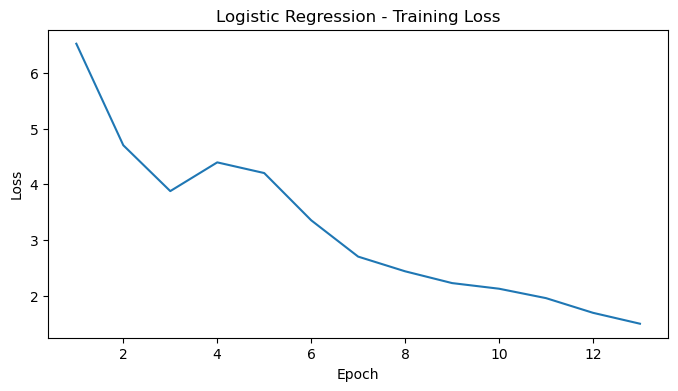

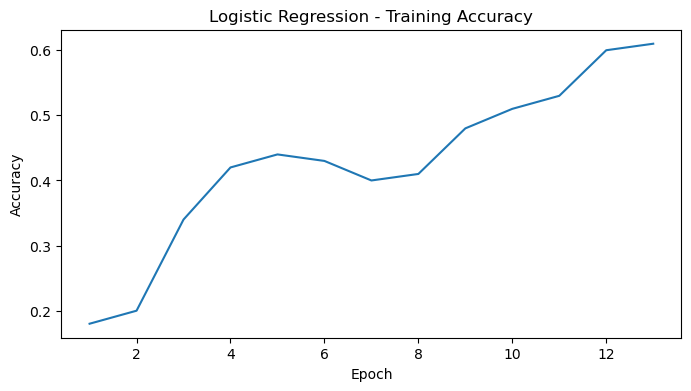

In [12]:
epochs_logreg = list(logreg.history.keys())
losses_logreg = [logreg.history[e]["loss"] for e in epochs_logreg]
metrics_logreg = [logreg.history[e]["metric"] for e in epochs_logreg]

plt.figure(figsize=(8, 4))
plt.plot(epochs_logreg, losses_logreg)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Logistic Regression - Training Loss")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_logreg, metrics_logreg)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Logistic Regression - Training Accuracy")
plt.show()

## DNN multi-classe

In [13]:
dnn = NeuralNetwork(
    epochs=50,
    batch_size=32,
    learning_rate=0.01,
    momentum=0.9,
    verbose=True,
    loss=CategoricalCrossEntropy,
    metric=accuracy
)

dnn.add(DenseLayer(128, input_shape=(X_train.shape[1],)))
dnn.add(ReLUActivation())
dnn.add(DenseLayer(64))
dnn.add(ReLUActivation())
dnn.add(DenseLayer(num_classes))
dnn.add(SoftmaxActivation())

dnn.fit(train_data, val_dataset=val_data, early_stopping=True, patience=5)

Epoch 1/50 - loss: 19.9005 - acc: 0.1600 - val_loss: 13.5728 - val_acc: 0.1600
Epoch 2/50 - loss: 11.4303 - acc: 0.3500 - val_loss: 14.8141 - val_acc: 0.2000
Epoch 3/50 - loss: 10.1437 - acc: 0.4400 - val_loss: 11.6046 - val_acc: 0.1600
Epoch 4/50 - loss: 8.7519 - acc: 0.3200 - val_loss: 10.4948 - val_acc: 0.1200
Epoch 5/50 - loss: 6.0716 - acc: 0.3500 - val_loss: 7.7885 - val_acc: 0.1200
Epoch 6/50 - loss: 3.5574 - acc: 0.5200 - val_loss: 6.6517 - val_acc: 0.1200
Epoch 7/50 - loss: 2.6212 - acc: 0.6100 - val_loss: 6.1163 - val_acc: 0.1200
Epoch 8/50 - loss: 2.2631 - acc: 0.6200 - val_loss: 6.0425 - val_acc: 0.1600
Epoch 9/50 - loss: 1.8687 - acc: 0.6300 - val_loss: 5.7760 - val_acc: 0.2000
Epoch 10/50 - loss: 1.3765 - acc: 0.6700 - val_loss: 5.5728 - val_acc: 0.2400
Epoch 11/50 - loss: 0.8215 - acc: 0.7600 - val_loss: 5.4311 - val_acc: 0.1600
Epoch 12/50 - loss: 0.4886 - acc: 0.8200 - val_loss: 5.3911 - val_acc: 0.1600
Epoch 13/50 - loss: 0.2993 - acc: 0.8800 - val_loss: 5.5021 - val_

## Avaliar DNN

In [14]:
val_pred_dnn = dnn.predict(val_data)
val_acc_dnn = accuracy(y_val, val_pred_dnn)

print("Validation accuracy - DNN:", val_acc_dnn)

Validation accuracy - DNN: 0.16


## Ver evolução do treino da DNN

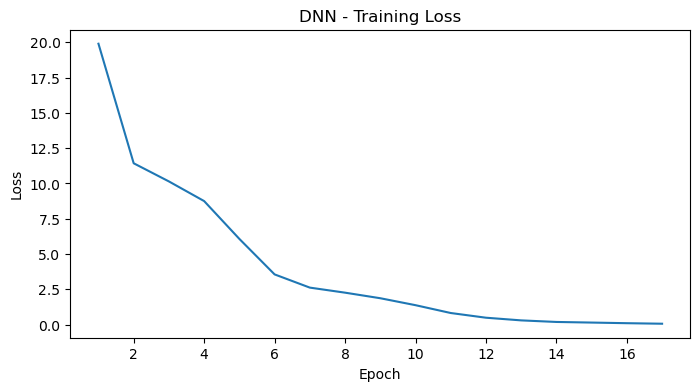

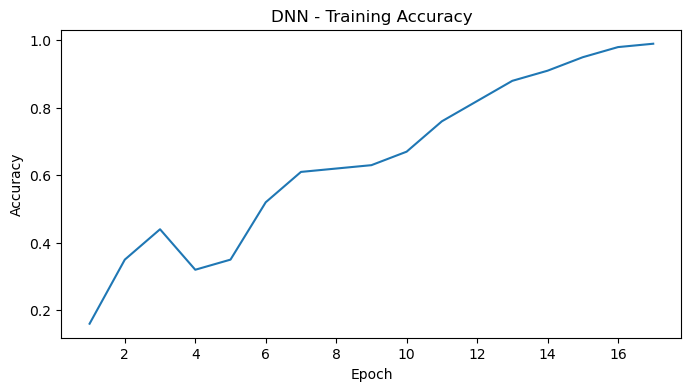

In [15]:
epochs_dnn = list(dnn.history.keys())
losses_dnn = [dnn.history[e]["loss"] for e in epochs_dnn]
metrics_dnn = [dnn.history[e]["metric"] for e in epochs_dnn]

plt.figure(figsize=(8, 4))
plt.plot(epochs_dnn, losses_dnn)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DNN - Training Loss")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_dnn, metrics_dnn)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DNN - Training Accuracy")
plt.show()

## Escolher o melhor modelo

In [16]:
if val_acc_dnn >= val_acc_logreg:
    best_model = dnn
    best_model_name = "DNN"
else:
    best_model = logreg
    best_model_name = "Logistic Regression"

print("Best model:", best_model_name)

Best model: DNN


## Prever o subm1.csv

In [17]:
test_pred = best_model.predict(test_data)
test_pred_idx = np.argmax(test_pred, axis=1)
test_pred_labels = [idx_to_label[i] for i in test_pred_idx]

print(test_pred_labels[:10])

['Anthropic', 'Human', 'Human', 'Anthropic', 'Human', 'Human', 'Human', 'Meta', 'Human', 'Anthropic']


## Criar ficheiro de submissão

In [18]:
submission = pd.DataFrame({
    "ID": test_df["ID"],
    "Label": test_pred_labels
})

display(submission.head())

submission.to_csv("submission.csv", sep=";", index=False)
print("submission.csv guardado com sucesso.")

,ID,Label
0,D2-1,Anthropic
1,D2-2,Human
2,D2-3,Human
3,D2-4,Anthropic
4,D2-5,Human


submission.csv guardado com sucesso.


## matriz de confusão simples

In [19]:
def confusion_matrix_numpy(y_true, y_pred, num_classes):
    if y_true.ndim > 1:
        y_true = np.argmax(y_true, axis=1)
    if y_pred.ndim > 1:
        y_pred = np.argmax(y_pred, axis=1)
    
    cm = np.zeros((num_classes, num_classes), dtype=int)
    
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
        
    return cm

cm_dnn = confusion_matrix_numpy(y_val, val_pred_dnn, num_classes)
cm_df = pd.DataFrame(
    cm_dnn,
    index=[idx_to_label[i] for i in range(num_classes)],
    columns=[idx_to_label[i] for i in range(num_classes)]
)

display(cm_df)

,Anthropic,Google,Human,Meta,OpenAI
Anthropic,2,1,3,2,1
Google,1,1,0,1,0
Human,4,0,0,1,1
Meta,0,2,0,0,1
OpenAI,1,0,1,1,1
